In [26]:
import requests
import time
from pathlib import Path

STRUCTURES = Path('../data/02_processed/structures')
STRUCTURES.mkdir(parents=True, exist_ok=True)

def fetch_esmfold(sequence: str, out_path: Path, timeout: int = 180, retries: int = 3) -> Path:
    """POST sequence to ESMFold API, save PDB, return path.
    
    Endpoint: https://api.esmatlas.com/foldSequence/v1/pdb/
    verify=False works around a known missing intermediate cert on Linux.
    Retries on 5xx / timeout with exponential backoff — the free API is unreliable.
    """
    if out_path.exists():
        print(f'  cached: {out_path.name}')
        return out_path
    for attempt in range(retries):
        try:
            resp = requests.post(
                'https://api.esmatlas.com/foldSequence/v1/pdb/',
                data=sequence,
                timeout=timeout,
                verify=False,
            )
            resp.raise_for_status()
            if not resp.text.startswith(('HEADER', 'ATOM', 'MODEL')):
                raise ValueError(f'Unexpected response (not PDB):\n{resp.text[:300]}')
            out_path.write_text(resp.text)
            print(f'  saved:  {out_path.name} ({len(resp.text):,} chars)')
            return out_path
        except (requests.HTTPError, requests.Timeout) as e:
            if attempt < retries - 1:
                wait = 15 * (2 ** attempt)
                print(f'  attempt {attempt + 1} failed ({e}), retrying in {wait}s...')
                time.sleep(wait)
            else:
                raise
    return out_path

In [27]:
import pandas as pd

WILDTYPE = 'VPVNPEPDATSVENVALKTGSGDSQSDPIKADLEVKGQSALPFDVDCWAILCKGAPNVLQRVNEKTKNSNRDRSGANKGPFKDPQKWGIKALPPKNPSWSAQDFKSPEEYAFASSLQGGTNAILAPVNLASQNSQGGVLNGFYSANKVAQFDPSKPQQTKGTWFQITKFTGAAGPYCKALGSNDKSVCDKNKNIAGDWGFDPAKWAYQYDEKNNKFNYVGK'

# Fetch wildtype structure
wt_pdb = fetch_esmfold(WILDTYPE, STRUCTURES / 'wildtype_esmfold.pdb')

# Fetch a small batch of test mutants (rate-limit: ~1 req/s is safe)
test = pd.read_csv('../data/01_raw/test.csv')
sample = test.head(5)

for _, row in sample.iterrows():
    fetch_esmfold(row['protein_sequence'], STRUCTURES / f'test_{row["seq_id"]}_esmfold.pdb')
    time.sleep(1.0)

/home/zaccosenza/code/project-enzyme/.venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.esmatlas.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  saved:  wildtype_esmfold.pdb (138,147 chars)
  cached: test_31390_esmfold.pdb
  cached: test_31391_esmfold.pdb
  cached: test_31392_esmfold.pdb
  cached: test_31393_esmfold.pdb
  cached: test_31394_esmfold.pdb


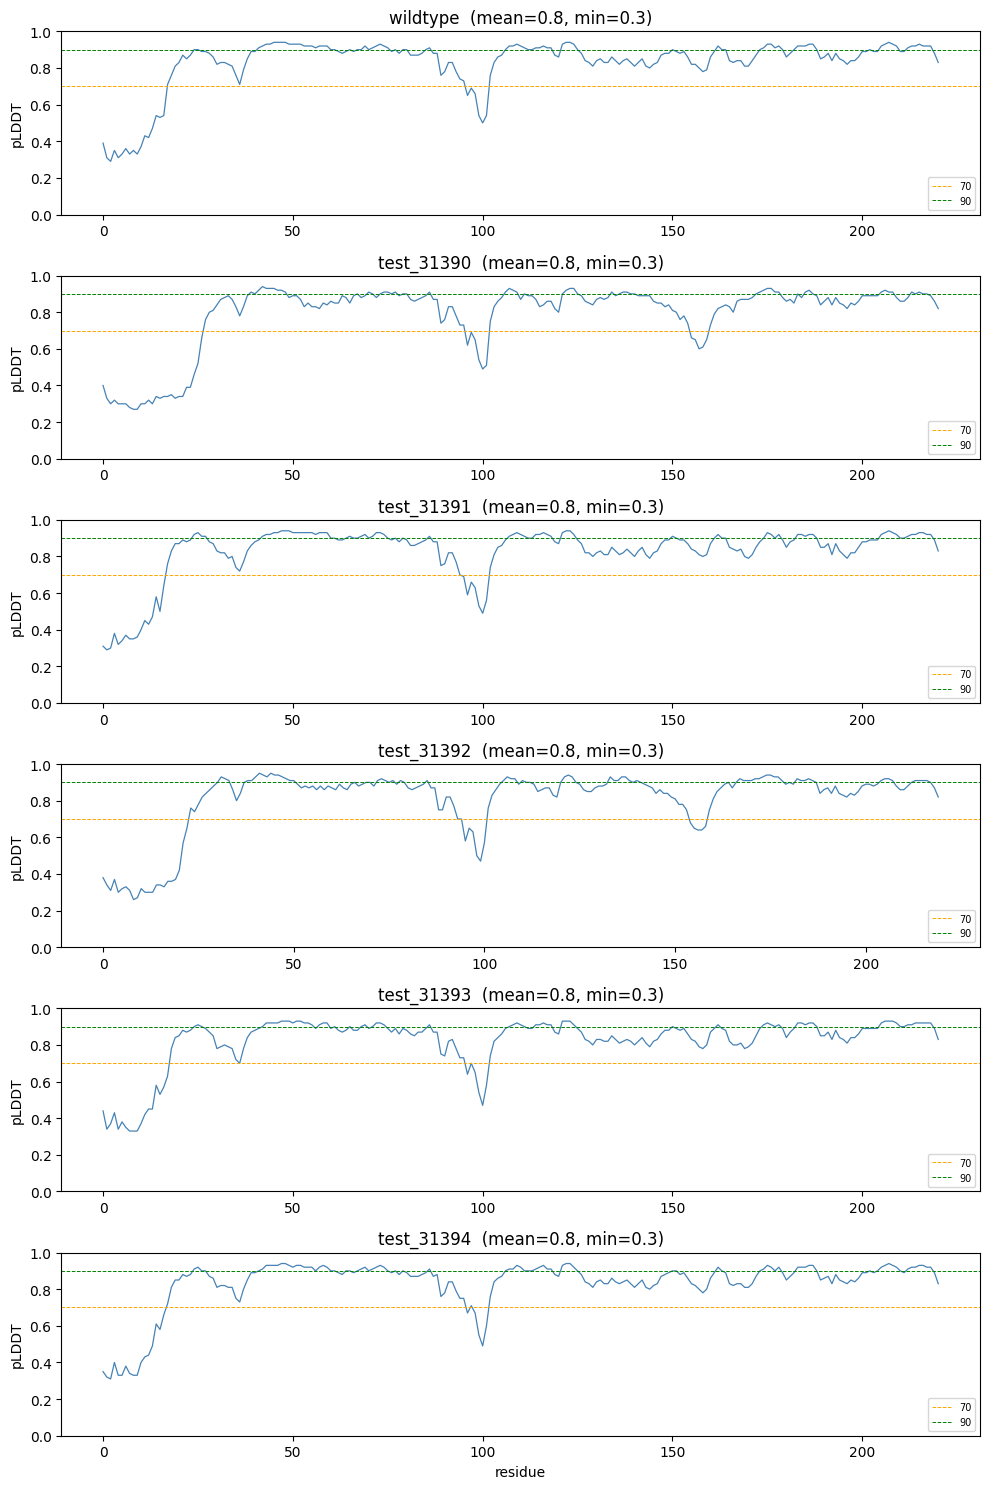

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def plddt_from_pdb(pdb_path: Path) -> np.ndarray:
    scores = []
    for line in pdb_path.read_text().splitlines():
        if line.startswith('ATOM') and line[12:16].strip() == 'CA':
            scores.append(float(line[60:66]))
    return np.array(scores)

all_pdbs = [('wildtype', wt_pdb)] + [
    (f'test_{row["seq_id"]}', STRUCTURES / f'test_{row["seq_id"]}_esmfold.pdb')
    for _, row in sample.iterrows()
]

fig, axes = plt.subplots(len(all_pdbs), 1, figsize=(10, 2.5 * len(all_pdbs)), sharex=False)
for ax, (label, pdb_path) in zip(axes, all_pdbs):
    scores = plddt_from_pdb(pdb_path)
    ax.plot(scores, linewidth=0.9, color='steelblue')
    ax.axhline(0.7, color='orange', linestyle='--', linewidth=0.7, label='70')
    ax.axhline(0.9, color='green',  linestyle='--', linewidth=0.7, label='90')
    ax.set_ylim(0, 1)
    ax.set_ylabel('pLDDT')
    ax.set_title(f'{label}  (mean={scores.mean():.1f}, min={scores.min():.1f})')
    ax.legend(fontsize=7, loc='lower right')

axes[-1].set_xlabel('residue')
plt.tight_layout()
plt.show()

In [ ]:
import networkx as nx
import numpy as np
from Bio.PDB import PDBParser

def pdb_to_graph(pdb_path: Path, ca_cutoff: float = 8.0) -> nx.Graph:
    """Residue contact graph from a PDB file.
    
    Nodes: residue index, attrs: resname, chain, plddt, pos (3D Cα coords)
    Edges: Cα pairs within ca_cutoff Å, attr: distance
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(pdb_path.stem, str(pdb_path))
    residues = [res for res in structure.get_residues() if res.has_id('CA')]

    G = nx.Graph()
    coords = []
    for i, res in enumerate(residues):
        ca = res['CA']
        xyz = ca.get_vector().get_array()
        G.add_node(i, resname=res.resname, chain=res.get_parent().id,
                   plddt=ca.get_bfactor(), pos=xyz)
        coords.append(xyz)

    coords = np.array(coords)
    diff = coords[:, None, :] - coords[None, :, :]
    dists = np.sqrt((diff ** 2).sum(-1))
    ii, jj = np.where((dists < ca_cutoff) & (dists > 0))
    for i, j in zip(ii, jj):
        if i < j:
            G.add_edge(int(i), int(j), distance=float(dists[i, j]))

    return G, coords

G_wt, coords_wt = pdb_to_graph(wt_pdb)
print(f'wildtype — nodes: {G_wt.number_of_nodes()}, edges: {G_wt.number_of_edges()}')
print(f'mean degree: {np.mean([d for _, d in G_wt.degree()]):.2f}')
print(f'mean pLDDT:  {np.mean([d["plddt"] for _, d in G_wt.nodes(data=True)]):.3f}')

# Contact map heatmap
n = G_wt.number_of_nodes()
contact_map = np.zeros((n, n))
for i, j in G_wt.edges():
    contact_map[i, j] = contact_map[j, i] = 1

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(contact_map, cmap='Blues', origin='upper')
ax.set_xlabel('residue')
ax.set_ylabel('residue')
ax.set_title('Wildtype contact map (Cα < 8 Å)')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.cm as cm

# Project 3D Cα coords to 2D via PCA for layout
xy = PCA(n_components=2).fit_transform(coords_wt)
pos = {i: xy[i] for i in range(len(xy))}

plddt_vals = np.array([G_wt.nodes[i]['plddt'] for i in G_wt.nodes()])

fig, ax = plt.subplots(figsize=(9, 7))
nx.draw_networkx_edges(G_wt, pos, ax=ax, alpha=0.15, width=0.4, edge_color='grey')
nc = nx.draw_networkx_nodes(G_wt, pos, ax=ax, node_size=30,
                            node_color=plddt_vals, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(nc, ax=ax, label='pLDDT', shrink=0.6)
ax.set_title('Wildtype contact graph — nodes by pLDDT, layout by Cα PCA projection')
ax.axis('off')
plt.tight_layout()
plt.show()